#### Levenberg-Marquardt 
##### Model: Chapman-Rachards
* H(t) = K(1 - e^(-bt))^c
Where: 
* K: max height
* b: growth rate
* c: shape



In [2]:
import numpy as np 
import matplotlib.pyplot as plt 


In [6]:
# Synthetic data

t = np.array([1,2,3,4,5,6,7,8], dtype=float)
theta = np.array([10.0, 0.2, 1.0]) # [K, b, c]
iterations = 20
lam = 1.0
history = []
H_true = (20 *(1 - np.exp(-0.4 * t))**1.5)
noise = np.random.normal(0, 0.5, size=len(t))
H = H_true + noise
# ----------------------
# Residual
# ----------------------

def res(theta):
    K, b, c= theta
    return (H) - (K * (1 - np.exp(-b * t))**c)

def Jacobian(theta):
    K, b, c = theta
    exp_term = np.exp(-b * t)
    base = (1 - exp_term)
    J = np.zeros((len(t), 3))
    J[:, 0] = -base**c
    J[:, 1] = -K * c * base**(c - 1) * (t * exp_term)
    J[:, 2] = -K * base**c * np.log(base + 1e-8)
    return J

for it in range(iterations):
    r = res(theta)
    J = Jacobian(theta)

    JTJ = J.T @ J
    JTr = J.T @ r
    A = JTJ + lam * np.eye(3)
    delta = np.linalg.solve(A, -JTr)

    theta_new = theta + delta

    err = np.sum(r**2)
    err_new = np.sum(res(theta_new)**2)
    history.append(theta.copy())

    print(f"iter {it}: theta={theta}, err={err:.4f}, λ={lam:.4f}")

    if err_new < err:
        theta = theta_new
        lam *= 0.7
    else:
        lam *= 2.0

print("\nFinal parameters:", theta)


iter 0: theta=[10.   0.2  1. ], err=560.7292, λ=1.0000
iter 1: theta=[10.26943512  0.92956902  2.31165357], err=233.2835, λ=0.7000
iter 2: theta=[16.37358373  0.46201255  2.15559624], err=59.0422, λ=0.4900
iter 3: theta=[17.63931471  0.58224748  2.0348966 ], err=1.8398, λ=0.3430
iter 4: theta=[18.44762068  0.51536131  1.8445954 ], err=0.3893, λ=0.2401
iter 5: theta=[18.73676072  0.49128613  1.76698243], err=0.2601, λ=0.1681
iter 6: theta=[18.8283413   0.48249244  1.73864363], err=0.2509, λ=0.1176
iter 7: theta=[18.85206034  0.48008878  1.73075486], err=0.2503, λ=0.0824
iter 8: theta=[18.85678065  0.47958894  1.72908958], err=0.2503, λ=0.0576
iter 9: theta=[18.85749699  0.47951126  1.72882881], err=0.2503, λ=0.0404
iter 10: theta=[18.8575803   0.47950211  1.72879804], err=0.2503, λ=0.0282
iter 11: theta=[18.85758782  0.47950127  1.72879524], err=0.2503, λ=0.0198
iter 12: theta=[18.85758836  0.47950121  1.72879504], err=0.2503, λ=0.0138
iter 13: theta=[18.85758836  0.47950121  1.72879504

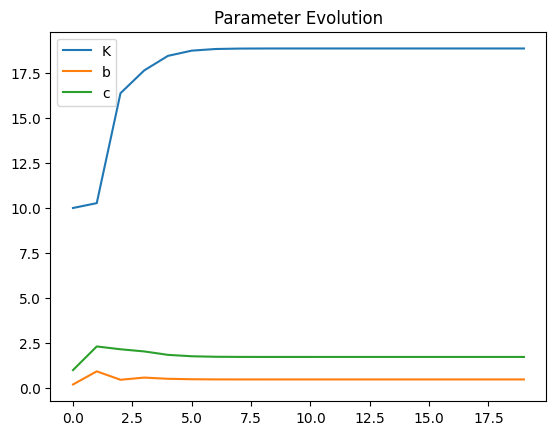

In [7]:
history = np.array(history)

plt.plot(history[:,0], label="K")
plt.plot(history[:,1], label="b")
plt.plot(history[:,2], label="c")
plt.legend()
plt.title("Parameter Evolution")
plt.show()

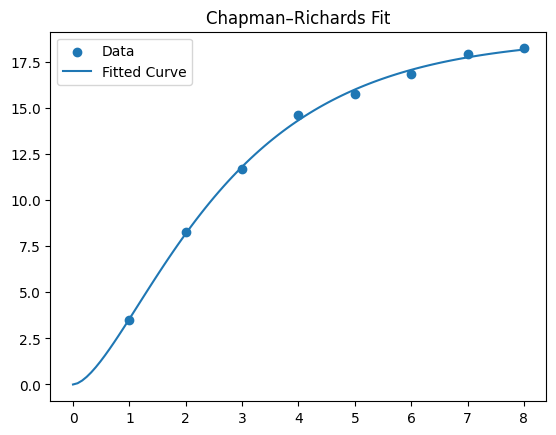

In [8]:
t_dense = np.linspace(0, 8, 100)

def model_dense(theta):
    K, b, c = theta
    return K * (1 - np.exp(-b * t_dense))**c

H = H_true + noise
plt.scatter(t, H, label="Data")
plt.plot(t_dense, model_dense(theta), label="Fitted Curve")
plt.legend()
plt.title("Chapman–Richards Fit")
plt.show()